# Proyecto: Mercado de Limones Argentinos
## Notebook 01 — Exploración y Diagnóstico del Dataset
### Fuente: DNRPA — Transferencias Automotrices Enero 2023
### Fecha de análisis: 09/06/2026
### Autor: Rodolfo Gabriel Riveros Lobos

---

## Contexto del análisis

El mercado automotriz argentino atraviesa en 2026 un período de 
alta tensión comercial. Según fuentes especializadas del sector, 
los concesionarios de vehículos 0km reportan niveles elevados de 
stock inmovilizado, lo que habría derivado en estrategias agresivas 
de liquidación.

En paralelo, operadores del mercado de vehículos usados señalan 
dificultades para sostener márgenes ante la presión de precios 
del segmento nuevo.

Este notebook inicia el análisis empírico de los registros de 
transferencias DNRPA para evaluar si existe evidencia en el 
comportamiento del mercado secundario consistente con los 
mecanismos de selección adversa descritos por Akerlof (1970).

**Nota metodológica:** Las condiciones de mercado descriptas 
provienen de fuentes periodísticas y testimonios sectoriales. 
Su validación empírica es precisamente el objetivo de este análisis. 
No se asume causalidad entre el mercado de 0km y el mercado de 
usados hasta que los datos lo respalden.

## Pregunta de investigación

¿Existe evidencia en los registros DNRPA 2023–2026 de que el shock de 
sobrestock en el mercado de 0km generó condiciones de selección adversa 
en el mercado de usados?

## Hipótesis de trabajo

1. En períodos de stress del mercado nuevo, la antigüedad promedio de los 
   vehículos transferidos aumenta.
2. El volumen de transferencias de marcas con menor historial local cae 
   proporcionalmente más que el mercado general.
3. Existe concentración de transferencias en el último trimestre de cada año, 
   consistente con el problema principal-agente en concesionarias.

## Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("Librerías cargadas correctamente.")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Librerías cargadas correctamente.
Pandas: 3.0.3
NumPy: 2.4.6


---
## Paso 1 — Carga del dataset
Cargamos el archivo transferencias_2023_01.csv crudo sin modificaciones. 
El encoding latin1 es estándar en registros administrativos argentinos.

## Celda 4 - Lectura inicial del dataset

In [2]:
df_raw = pd.read_csv(
    '../data/raw/transferencias_2023_01.csv',
    encoding='utf-8-sig',    # resuelve el BOM
    sep=',',
    low_memory=False,        # resuelve el DtypeWarning
    dtype={'automotor_tipo_codigo': str}  # fuerza string en columna mixta
)

print(f"Shape: {df_raw.shape}")
print(f"\nColumnas ({len(df_raw.columns)}):")
for col in df_raw.columns:
    print(f"  - {col}")

Shape: (133102, 25)

Columnas (25):
  - tramite_tipo
  - tramite_fecha
  - fecha_inscripcion_inicial
  - registro_seccional_codigo
  - registro_seccional_descripcion
  - registro_seccional_provincia
  - automotor_origen
  - automotor_anio_modelo
  - automotor_tipo_codigo
  - automotor_tipo_descripcion
  - automotor_marca_codigo
  - automotor_marca_descripcion
  - automotor_modelo_codigo
  - automotor_modelo_descripcion
  - automotor_uso_codigo
  - automotor_uso_descripcion
  - titular_tipo_persona
  - titular_domicilio_localidad
  - titular_domicilio_provincia
  - titular_genero
  - titular_anio_nacimiento
  - titular_pais_nacimiento
  - titular_porcentaje_titularidad
  - titular_domicilio_provincia_id
  - titular_pais_nacimiento_id


---
## Paso 2 — Diagnóstico de calidad

**Nota de carga:** El archivo original presentó dos problemas resueltos 
en la carga:

1. **BOM (Byte Order Mark):** La primera columna contenía caracteres 
   `ï»¿` producto de un encoding UTF-8 con BOM leído como latin1. 
   Resuelto con `encoding='utf-8-sig'`.

2. **DtypeWarning:** La columna `automotor_tipo_codigo` contiene valores 
   mixtos (numéricos y texto). Resuelto forzando `dtype=str` en la carga 
   y `low_memory=False`.

Ambos problemas son típicos de registros administrativos argentinos 
y no afectan la integridad de los datos.

## Celda 6 - Evaluación de Nulos

In [3]:
# Nulos por columna
nulos = df_raw.isnull().sum()
pct_nulos = (nulos / len(df_raw) * 100).round(2)

diagnostico = pd.DataFrame({
    'nulos': nulos,
    'pct_nulos': pct_nulos,
    'dtype': df_raw.dtypes,
    'valores_unicos': df_raw.nunique()
}).sort_values('pct_nulos', ascending=False)

print(diagnostico)

                                nulos  pct_nulos    dtype  valores_unicos
titular_pais_nacimiento_id       8245       6.19      str              51
automotor_tipo_codigo            4030       3.03      str              75
automotor_modelo_codigo          2173       1.63      str            1979
automotor_marca_codigo           1778       1.34      str             318
automotor_anio_modelo             902       0.68  float64              88
titular_domicilio_localidad        89       0.07      str            6186
titular_anio_nacimiento            11       0.01  float64             121
tramite_fecha                       0       0.00      str              24
tramite_tipo                        0       0.00      str              22
registro_seccional_provincia        0       0.00      str              24
automotor_origen                    0       0.00      str               3
registro_seccional_codigo           0       0.00    int64             842
registro_seccional_descripcion      0 

---
## Hallazgos del diagnóstico de calidad

### Variables críticas para el análisis
| Variable | Nulos | Decisión |
|---|---|---|
| automotor_anio_modelo | 902 (0.68%) | Eliminar — sin año no hay antigüedad |
| automotor_marca_descripcion | 0 | Conservar — requiere normalización |
| registro_seccional_provincia | 0 | Conservar — limpia |
| tramite_tipo | 0 | Conservar — limpia |

### Señales de suciedad detectadas
- `automotor_marca_descripcion` tiene 493 valores únicos para lo que 
  debería ser ~50-60 marcas reales. Indica variantes tipográficas 
  del mismo nombre.
- `automotor_modelo_descripcion` tiene 13.290 valores únicos. 
  No se utilizará en este análisis.

### Columnas excluidas del análisis
- Columnas _codigo: se usan las _descripcion equivalentes
- titular_pais_nacimiento_id: no relevante para las hipótesis
- automotor_modelo_descripcion: suciedad extrema, fuera de scope

## Celda 8 - ¿Cuantos tipos de trámite encontramos en el dataset?

In [4]:
# Inventario completo de tramite_tipo antes de filtrar
print("VALORES EN tramite_tipo:")
print(df_raw['tramite_tipo'].value_counts())
print(f"\nTotal categorías: {df_raw['tramite_tipo'].nunique()}")

VALORES EN tramite_tipo:
tramite_tipo
TRANSFERENCIA IMPORTADO                                 53681
TRANSFERENCIA NACIONAL                                  46374
TRANSFERENCIA IMPORTADO C/PEDIDO                        14958
TRANSFERENCIA NACIONAL C/PEDIDO                         11131
TRANSFERENCIA IMPORTADO DE COM. HAB.                     1937
TRANSFERENCIA IMPORTADO A COM. HAB.                      1030
TRANSFERENCIA NACIONAL DE COM. HAB.                       975
TRANSFERENCIA IMPORTADO A COM. HAB. F17                   612
TRANSFERENCIA IMPORTADO A COM. HAB  C/PEDIDO.             583
TRANSFERENCIA NACIONAL A COM. HAB.                        464
TRANSFERENCIA NACIONAL A COM. HAB. C/PEDIDO               306
TRANSFERENCIA NACIONAL A COM. HAB. F17                    306
TRANSFERENCIA IMPORTADO A COM. HAB. F17 C/PEDIDO.         262
TRANSFERENCIA IMPORTADO DE COM. HAB. C/PEDIDO.            185
TRANSFERENCIA NACIONAL A COM. HAB. F17 C/PEDIDO           136
TRANSFERENCIA NACIONAL  DE COM. 

---
## Paso 3 — Filtro de registros

### Decisión de filtro

Se conservan todas las categorías de transferencia con una 
exclusión puntual.

**Excluidos:**
- `TRANSFERENCIA SUBASTADOS / AFF / CLASICOS` (11 registros)
  Razón: autos subastados y clásicos tienen dinámicas de precio 
  y antigüedad ajenas al mercado secundario regular.

**Conservados — incluyendo COM. HAB.:**
Los registros que involucran comerciantes habilitados (agencieros) 
se conservan deliberadamente. En el mercado argentino de usados, 
los agencieros son el actor central del mecanismo de selección 
adversa de Akerlof. Si el mercado se deteriora, la señal debería 
aparecer primero en sus transferencias.

**Limitación metodológica:**
Los registros COM. HAB. pueden subestimar el volumen real de 
operaciones comerciales. Existe evidencia sectorial de que una 
proporción de operaciones entre agencieros se registra bajo 
categorías de transferencia entre particulares para simplificar 
el trámite. Por lo tanto, el volumen observado en COM. HAB. 
representa un piso, no el total real del mercado intermediado.

## Celda 10 - Exclusión de tramites

In [5]:
# Exclusión puntual de subastados y clásicos
mask_excluir = df_raw['tramite_tipo'] == 'TRANSFERENCIA SUBASTADOS / AFF / CLASICOS'

df_transfer = df_raw[~mask_excluir].copy()

# Reporte del filtro
total_original = len(df_raw)
total_transfer = len(df_transfer)
excluidos = total_original - total_transfer

print(f"Registros originales:    {total_original:,}")
print(f"Registros conservados:   {total_transfer:,}")
print(f"Registros excluidos:     {excluidos:,}")
print(f"Porcentaje conservado:   {total_transfer/total_original*100:.2f}%")

Registros originales:    133,102
Registros conservados:   133,091
Registros excluidos:     11
Porcentaje conservado:   99.99%


---
## Paso 4 — Exploración de variables clave

Inspeccionamos las variables centrales del análisis antes de 
construir métricas derivadas.

In [6]:
# Distribución de automotor_origen
print("=" * 50)
print("AUTOMOTOR_ORIGEN")
print(df_transfer['automotor_origen'].value_counts())

# Distribución de automotor_tipo_descripcion — top 15
print("\n" + "=" * 50)
print("AUTOMOTOR_TIPO_DESCRIPCION (top 15)")
print(df_transfer['automotor_tipo_descripcion'].value_counts().head(15))

# Distribución de registro_seccional_provincia
print("\n" + "=" * 50)
print("REGISTRO_SECCIONAL_PROVINCIA")
print(df_transfer['registro_seccional_provincia'].value_counts())

# Distribución de automotor_anio_modelo
print("\n" + "=" * 50)
print("AUTOMOTOR_ANIO_MODELO")
print(df_transfer['automotor_anio_modelo'].describe())
print(f"\nNulos: {df_transfer['automotor_anio_modelo'].isnull().sum()}")

AUTOMOTOR_ORIGEN
automotor_origen
Nacional        59837
Protocolo 21    53740
Importado       19514
Name: count, dtype: int64

AUTOMOTOR_TIPO_DESCRIPCION (top 15)
automotor_tipo_descripcion
SEDAN 5 PUERTAS         27597
SEDAN 5 PTAS            16824
SEDAN 4 PUERTAS         15924
SEDAN 4 PTAS            14072
PICK-UP                 11774
SEDAN 3 PTAS             7375
RURAL 5 PUERTAS          6156
SEDAN 3 PUERTAS          4050
FURGON                   3718
PICK-UP CABINA DOBLE     3321
TODO TERRENO             3146
RURAL 5 PTAS             2800
CHASIS C/CABINA          1661
PICK UP                  1599
SEDAN 2 PTAS             1328
Name: count, dtype: int64

REGISTRO_SECCIONAL_PROVINCIA
registro_seccional_provincia
Buenos Aires                 51080
Córdoba                      15255
Ciudad Autónoma de Bs.As.    12945
Santa Fe                     11445
Mendoza                       6629
Entre Ríos                    5165
Neuquén                       3060
Río Negro                     

In [7]:
# Ver describe completo de anio_modelo
print("AUTOMOTOR_ANIO_MODELO — estadísticas completas")
print(df_transfer['automotor_anio_modelo'].describe())

# Distribución de provincias completa
print("\n" + "=" * 50)
print("REGISTRO_SECCIONAL_PROVINCIA")
print(df_transfer['registro_seccional_provincia'].value_counts())

# Protocolo 21 — cuántos tienen anio_modelo nulo
print("\n" + "=" * 50)
print("NULOS EN ANIO_MODELO POR ORIGEN")
print(df_transfer.groupby('automotor_origen')['automotor_anio_modelo']
      .apply(lambda x: x.isnull().sum()))

AUTOMOTOR_ANIO_MODELO — estadísticas completas
count    132191.000000
mean       2008.568783
std          22.261953
min          20.000000
25%        2005.000000
50%        2011.000000
75%        2016.000000
max        2023.000000
Name: automotor_anio_modelo, dtype: float64

REGISTRO_SECCIONAL_PROVINCIA
registro_seccional_provincia
Buenos Aires                 51080
Córdoba                      15255
Ciudad Autónoma de Bs.As.    12945
Santa Fe                     11445
Mendoza                       6629
Entre Ríos                    5165
Neuquén                       3060
Río Negro                     2619
Tucumán                       2572
Chubut                        2550
Corrientes                    2363
Misiones                      2317
La Pampa                      2067
Chaco                         2009
San Juan                      1767
San Luis                      1704
Salta                         1666
Santa Cruz                    1264
Jujuy                          977
S

In [8]:
# Investigar valores absurdos en anio_modelo
print("VALORES ANÓMALOS EN ANIO_MODELO")
print(f"Registros con año < 1900: "
      f"{(df_transfer['automotor_anio_modelo'] < 1900).sum()}")
print(f"Registros con año < 1950: "
      f"{(df_transfer['automotor_anio_modelo'] < 1950).sum()}")
print(f"Registros con año > 2023: "
      f"{(df_transfer['automotor_anio_modelo'] > 2023).sum()}")

# Ver los valores más bajos
print("\nLOS 10 AÑOS MÁS BAJOS REGISTRADOS:")
print(df_transfer['automotor_anio_modelo']
      .dropna()
      .sort_values()
      .head(10)
      .values)

# Provincias completas — forzamos visualización
print("\n" + "="*50)
print("PROVINCIAS COMPLETAS")
provincias = df_transfer['registro_seccional_provincia'].value_counts()
pd.set_option('display.max_rows', 50)
print(provincias)
pd.reset_option('display.max_rows')

VALORES ANÓMALOS EN ANIO_MODELO
Registros con año < 1900: 13
Registros con año < 1950: 62
Registros con año > 2023: 0

LOS 10 AÑOS MÁS BAJOS REGISTRADOS:
[20. 20. 20. 20. 20. 20. 20. 20. 20. 20.]

PROVINCIAS COMPLETAS
registro_seccional_provincia
Buenos Aires                 51080
Córdoba                      15255
Ciudad Autónoma de Bs.As.    12945
Santa Fe                     11445
Mendoza                       6629
Entre Ríos                    5165
Neuquén                       3060
Río Negro                     2619
Tucumán                       2572
Chubut                        2550
Corrientes                    2363
Misiones                      2317
La Pampa                      2067
Chaco                         2009
San Juan                      1767
San Luis                      1704
Salta                         1666
Santa Cruz                    1264
Jujuy                          977
Santiago del Estero            946
Formosa                        818
Tierra del Fuego  

---
## Paso 5 — Limpieza y construcción de variables

### Decisiones de limpieza

**anio_modelo — valores excluidos:**

| Criterio | Registros | Razón |
|---|---|---|
| año == 20 | 13 | Error de carga — tipeo incompleto |
| año < 1950 | ~49 adicionales | Fuera del scope del análisis |
| año nulo | 900 | Sin año no hay antigüedad calculable |

**Rango válido definido: 1950 — 2023**

Esta decisión excluye autos clásicos y errores de carga. 
Se declara como limitación: el análisis no representa el 
segmento de vehículos de colección ni autos de más de 73 años.

In [9]:
# Limpieza de anio_modelo
df_clean = df_transfer.copy()

# Eliminar nulos
df_clean = df_clean.dropna(subset=['automotor_anio_modelo'])

# Eliminar años fuera del rango válido
df_clean = df_clean[
    (df_clean['automotor_anio_modelo'] >= 1950) &
    (df_clean['automotor_anio_modelo'] <= 2023)
]

# Convertir a entero
df_clean['automotor_anio_modelo'] = df_clean['automotor_anio_modelo'].astype(int)

# Reporte
print(f"Registros antes de limpieza:  {len(df_transfer):,}")
print(f"Registros después de limpieza: {len(df_clean):,}")
print(f"Registros eliminados:          {len(df_transfer) - len(df_clean):,}")
print(f"Porcentaje conservado:         "
      f"{len(df_clean)/len(df_transfer)*100:.2f}%")

# Verificación
print(f"\nAño mínimo después de limpieza: "
      f"{df_clean['automotor_anio_modelo'].min()}")
print(f"Año máximo después de limpieza: "
      f"{df_clean['automotor_anio_modelo'].max()}")
print(f"Nulos restantes en anio_modelo: "
      f"{df_clean['automotor_anio_modelo'].isnull().sum()}")

Registros antes de limpieza:  133,091
Registros después de limpieza: 132,129
Registros eliminados:          962
Porcentaje conservado:         99.28%

Año mínimo después de limpieza: 1950
Año máximo después de limpieza: 2023
Nulos restantes en anio_modelo: 0


In [10]:
# Provincias completas — solución definitiva al truncado
print("PROVINCIAS COMPLETAS")
provincias = (df_clean['registro_seccional_provincia']
              .value_counts()
              .reset_index())
provincias.columns = ['provincia', 'transferencias']
provincias['pct'] = (provincias['transferencias'] / 
                     len(df_clean) * 100).round(2)
print(provincias.to_string(index=False))

PROVINCIAS COMPLETAS
                provincia  transferencias   pct
             Buenos Aires           50692 38.37
                  Córdoba           15129 11.45
Ciudad Autónoma de Bs.As.           12888  9.75
                 Santa Fe           11404  8.63
                  Mendoza            6473  4.90
               Entre Ríos            5141  3.89
                  Neuquén            3051  2.31
                Río Negro            2598  1.97
                  Tucumán            2565  1.94
                   Chubut            2542  1.92
               Corrientes            2355  1.78
                 Misiones            2307  1.75
                 La Pampa            2045  1.55
                    Chaco            1995  1.51
                 San Juan            1734  1.31
                 San Luis            1683  1.27
                    Salta            1663  1.26
               Santa Cruz            1261  0.95
                    Jujuy             972  0.74
      Santiago del 

---
## Construcción de variable: antigüedad

La antigüedad del vehículo al momento de la transferencia es la 
variable central del análisis de Akerlof.

Un mercado con selección adversa debería mostrar, en períodos 
de stress, un aumento en la antigüedad promedio de los vehículos 
transferidos: los vehículos más nuevos y de mejor calidad salen 
del mercado o sus dueños los retienen, quedando disponibles 
principalmente los más viejos o deteriorados.

**Fórmula:**
antiguedad = año_del_archivo - automotor_anio_modelo

**Año de referencia para este archivo:** 2023

In [11]:
# Construcción de variable antigüedad
ANIO_REFERENCIA = 2023

df_clean['antiguedad'] = ANIO_REFERENCIA - df_clean['automotor_anio_modelo']

# Estadísticas
print("ANTIGÜEDAD — estadísticas descriptivas")
print(df_clean['antiguedad'].describe().round(2))

# Distribución por rangos
bins = [0, 3, 7, 15, 25, 40, 75]
labels = ['0-3 años', '4-7 años', '8-15 años', 
          '16-25 años', '26-40 años', '41-73 años']

df_clean['rango_antiguedad'] = pd.cut(
    df_clean['antiguedad'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

rangos = (df_clean['rango_antiguedad']
          .value_counts()
          .sort_index()
          .reset_index())
rangos.columns = ['rango', 'cantidad']
rangos['pct'] = (rangos['cantidad'] / len(df_clean) * 100).round(2)

print("\nDISTRIBUCIÓN POR RANGO DE ANTIGÜEDAD")
print(rangos.to_string(index=False))

ANTIGÜEDAD — estadísticas descriptivas
count    132129.00
mean         14.21
std          10.24
min           0.00
25%           7.00
50%          12.00
75%          18.00
max          73.00
Name: antiguedad, dtype: float64

DISTRIBUCIÓN POR RANGO DE ANTIGÜEDAD
     rango  cantidad   pct
  0-3 años      9075  6.87
  4-7 años     26867 20.33
 8-15 años     53532 40.51
16-25 años     24645 18.65
26-40 años     13823 10.46
41-73 años      4187  3.17


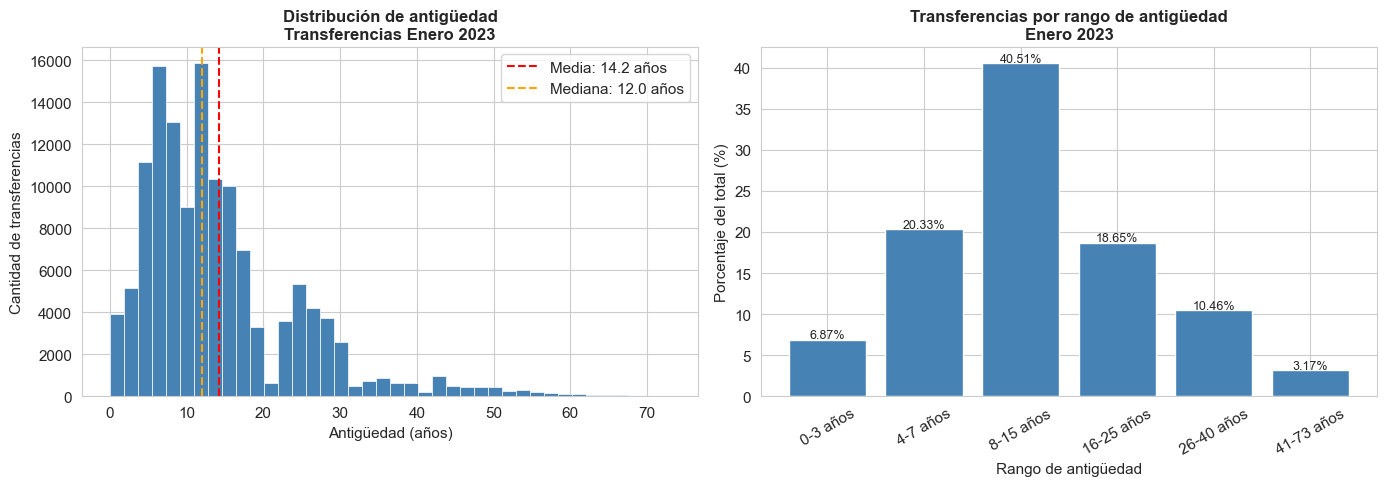

Gráfico guardado en reports/figures/


In [12]:
# Primera visualización del proyecto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de antigüedad
axes[0].hist(
    df_clean['antiguedad'], 
    bins=40, 
    color='steelblue', 
    edgecolor='white',
    linewidth=0.5
)
axes[0].set_title('Distribución de antigüedad\nTransferencias Enero 2023', 
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Antigüedad (años)')
axes[0].set_ylabel('Cantidad de transferencias')
axes[0].axvline(
    df_clean['antiguedad'].mean(), 
    color='red', 
    linestyle='--', 
    linewidth=1.5,
    label=f"Media: {df_clean['antiguedad'].mean():.1f} años"
)
axes[0].axvline(
    df_clean['antiguedad'].median(), 
    color='orange', 
    linestyle='--', 
    linewidth=1.5,
    label=f"Mediana: {df_clean['antiguedad'].median():.1f} años"
)
axes[0].legend()

# Barras por rango
axes[1].bar(
    rangos['rango'], 
    rangos['pct'],
    color='steelblue',
    edgecolor='white'
)
axes[1].set_title('Transferencias por rango de antigüedad\nEnero 2023', 
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rango de antigüedad')
axes[1].set_ylabel('Porcentaje del total (%)')
axes[1].tick_params(axis='x', rotation=30)

for i, row in rangos.iterrows():
    axes[1].text(i, row['pct'] + 0.2, f"{row['pct']}%", 
                 ha='center', fontsize=9)

plt.tight_layout()

# Guardar en reports/figures
plt.savefig('../reports/figures/01_distribucion_antiguedad.png', 
            dpi=150, bbox_inches='tight')
plt.show()

print("Gráfico guardado en reports/figures/")

---
## Hallazgo 1 — Distribución de antigüedad (Enero 2023)

| Estadístico | Valor |
|---|---|
| Media | 14.21 años |
| Mediana | 12.00 años |
| Rango dominante | 8-15 años (40.51%) |
| Vehículos casi nuevos (0-3 años) | 6.87% |

**Interpretación preliminar:**

La concentración del mercado en vehículos de 8 a 15 años 
y la baja participación de vehículos recientes (0-3 años) 
es consistente con el mecanismo de retención descripto por 
Akerlof (1970): los propietarios de vehículos nuevos o en 
buen estado anticipan que el mercado no reconocerá su valor 
real y prefieren no vender.

Este patrón constituye la línea de base del análisis. 
Su variación a lo largo de los 6 archivos del período 
2023-2026 será el indicador central de selección adversa.

**Hipótesis operativa para el Día 2:**
Si existe selección adversa creciente, la antigüedad promedio 
debería aumentar y el porcentaje de vehículos 0-3 años debería 
caer en los archivos correspondientes a períodos de mayor 
stress del mercado.

In [13]:
# Antigüedad promedio por origen del vehículo
print("ANTIGÜEDAD PROMEDIO POR ORIGEN")
antiguedad_origen = (df_clean.groupby('automotor_origen')['antiguedad']
                     .agg(['mean', 'median', 'count'])
                     .round(2)
                     .sort_values('mean', ascending=False))
antiguedad_origen.columns = ['media', 'mediana', 'cantidad']
antiguedad_origen['pct'] = (antiguedad_origen['cantidad'] / 
                             len(df_clean) * 100).round(2)
print(antiguedad_origen.to_string())

# Protocolo 21 específicamente — rango de antigüedad
print("\nPROTOCOLO 21 — distribución por rango")
proto21 = df_clean[df_clean['automotor_origen'] == 'Protocolo 21']
print(proto21['rango_antiguedad'].value_counts().sort_index())

ANTIGÜEDAD PROMEDIO POR ORIGEN
                  media  mediana  cantidad    pct
automotor_origen                                 
Nacional          16.98     13.0     58970  44.63
Importado         14.58     12.0     19430  14.71
Protocolo 21      11.04     10.0     53729  40.66

PROTOCOLO 21 — distribución por rango
rango_antiguedad
0-3 años       3899
4-7 años      14148
8-15 años     23925
16-25 años    10472
26-40 años     1186
41-73 años       99
Name: count, dtype: int64


---
## Hallazgo 2 — Protocolo 21 y la escala de asimetría informacional

### Datos

| Origen | Media antigüedad | Mediana | Participación |
|---|---|---|---|
| Nacional | 16.98 años | 13.0 años | 44.63% |
| Importado | 14.58 años | 12.0 años | 14.71% |
| Protocolo 21 | 11.04 años | 10.0 años | 40.66% |

### Revisión del marco de asimetría

La asimetría de información en el mercado automotriz argentino 
no es exclusiva de los vehículos Protocolo 21. Es una condición 
estructural que afecta todos los orígenes con distinta intensidad.

**Vehículo Nacional:**
El comprador puede acceder a informe de dominio, multas y 
gravámenes mediante DNRPA. Sin embargo, la verificación 
del estado real del vehículo (historial de accidentes, 
estado mecánico, manipulación de odómetro) requiere 
contratar un perito especializado o acceder a información 
no pública. La asimetría existe pero puede reducirse 
con inversión de tiempo y dinero.

**Vehículo Protocolo 21:**
El comprador no puede acceder al historial registral del 
país de origen. La evaluación se basa en la rareza o 
reputación del modelo en el mercado regional (señal 
de calidad indirecta) y frecuentemente en la contratación 
de servicios de intermediación y verificación para la 
radicación en Argentina.

**Implicancia no contemplada en Akerlof (1970):**
El mercado desarrolló mecanismos de señalización 
(Spence, 1973) para reducir parcialmente la asimetría. 
Sin embargo, estos mecanismos tienen costo de acceso. 
Los compradores con menor capacidad económica adquieren 
vehículos Protocolo 21 sin verificación, concentrando 
la exposición a selección adversa en el segmento más 
vulnerable del mercado.

### Hipótesis operativa revisada

La variable relevante no es si el vehículo es 
Protocolo 21 o Nacional, sino el nivel de verificación 
al que accedió el comprador. El dataset DNRPA no 
contiene esa información, lo que constituye una 
limitación estructural del análisis.

In [14]:
# Top 15 marcas — volumen de transferencias
print("TOP 15 MARCAS POR VOLUMEN")
top_marcas = (df_clean['automotor_marca_descripcion']
              .value_counts()
              .head(15)
              .reset_index())
top_marcas.columns = ['marca', 'transferencias']
top_marcas['pct'] = (top_marcas['transferencias'] / 
                     len(df_clean) * 100).round(2)
print(top_marcas.to_string(index=False))

# Antigüedad promedio por marca — top 15
print("\nANTIGÜEDAD PROMEDIO — TOP 15 MARCAS")
antiguedad_marca = (df_clean[df_clean['automotor_marca_descripcion']
                    .isin(top_marcas['marca'])]
                    .groupby('automotor_marca_descripcion')['antiguedad']
                    .agg(['mean', 'median'])
                    .round(2)
                    .sort_values('mean'))
print(antiguedad_marca.to_string())

TOP 15 MARCAS POR VOLUMEN
        marca  transferencias   pct
   VOLKSWAGEN           23111 17.49
         FORD           18672 14.13
      RENAULT           17387 13.16
    CHEVROLET           15499 11.73
         FIAT           14864 11.25
      PEUGEOT           13001  9.84
       TOYOTA            9407  7.12
      CITROEN            4203  3.18
MERCEDES BENZ            2418  1.83
        HONDA            2117  1.60
       NISSAN            1744  1.32
         JEEP             973  0.74
       SUZUKI             714  0.54
         AUDI             670  0.51
          BMW             550  0.42

ANTIGÜEDAD PROMEDIO — TOP 15 MARCAS
                              mean  median
automotor_marca_descripcion               
NISSAN                        8.41     6.0
TOYOTA                        8.47     7.0
JEEP                          9.52     5.0
CITROEN                      11.12    10.0
AUDI                         11.45    11.0
HONDA                        12.28    12.0
VOLKSWAGEN       

---
## Hallazgo 3 — Taxonomía de marcas por comportamiento de mercado

El análisis de antigüedad promedio por marca revela cuatro 
patrones distintos que no pueden explicarse únicamente por 
la calidad del vehículo. El mecanismo de mercado opera 
de forma diferente según el tipo de marca.

### Taxonomía emergente

**Tipo 1 — Anti-limón (baja asimetría, alta liquidez)**

| Marca | Antigüedad media | Participación |
|---|---|---|
| Toyota | 8.47 años | 7.12% |
| Nissan | 8.41 años | 1.32% |

La reputación establecida del modelo funciona como señal 
de calidad verificable (Spence, 1973) sin necesidad de 
inspección. El comprador sabe qué compra. La transacción 
se cierra rápido. El vehículo se transfiere más nuevo.

Caso paradigmático: Toyota Hilux — vehículo con valor de 
reventa predecible en todo el territorio nacional, 
comportamiento de activo líquido en el mercado secundario.

**Tipo 2 — Limón clásico (alta asimetría, baja liquidez)**

| Marca | Antigüedad media | Participación |
|---|---|---|
| Ford | 16.40 años | 14.13% |
| Fiat | 16.10 años | 11.25% |
| Renault | 15.49 años | 13.16% |
| Suzuki | 17.12 años | 0.54% |

Alta antigüedad en marcas masivas explicada parcialmente 
por modelos discontinuados con alta penetración histórica 
(Ford F100, Fiat 147, Renault 12) que siguen circulando 
y transfiriéndose décadas después de su producción.

**Tipo 3 — Limón premium (selección adversa de segundo orden)**

| Marca | Antigüedad media | Participación |
|---|---|---|
| Mercedes Benz | 20.24 años | 1.83% |
| BMW | 13.77 años | 0.42% |

El propietario de vehículo premium tiene precio de reserva 
elevado. La brecha entre su valuación y la disposición 
a pagar del mercado genera fricción prolongada. 
El vehículo que finalmente se transfiere es el que 
el propietario necesita vender urgente, concentrando 
selección adversa de segundo orden: los peores premium 
salen primero.

**Tipo 4 — Mercado heterogéneo (poblaciones mixtas)**

| Marca | Antigüedad media | Mediana | Diferencia |
|---|---|---|---|
| Jeep | 9.52 años | 5.0 años | 4.52 años |

La diferencia pronunciada entre media y mediana indica 
dos poblaciones coexistentes: vehículos del relanzamiento 
post-2010 (jóvenes) y unidades del período IKA-Chrysler 
(muy antiguas). El promedio no representa ninguna de 
las dos poblaciones con precisión.

### Implicancia metodológica

El análisis por marca promedio oculta heterogeneidad 
intra-marca relevante. En el Día 2 se segmentará 
por rangos de antigüedad dentro de cada tipo para 
controlar este efecto.

## Celda - 25 Guardando el dataset procesado

In [15]:
# Guardar df_clean para usar en Día 2 sin reprocesar
df_clean.to_csv(
    '../data/processed/transferencias_2023_01_clean.csv',
    index=False,
    encoding='utf-8'
)

print(f"Dataset guardado en data/processed/")
print(f"Shape final: {df_clean.shape}")
print(f"Columnas: {df_clean.columns.tolist()}")

Dataset guardado en data/processed/
Shape final: (132129, 27)
Columnas: ['tramite_tipo', 'tramite_fecha', 'fecha_inscripcion_inicial', 'registro_seccional_codigo', 'registro_seccional_descripcion', 'registro_seccional_provincia', 'automotor_origen', 'automotor_anio_modelo', 'automotor_tipo_codigo', 'automotor_tipo_descripcion', 'automotor_marca_codigo', 'automotor_marca_descripcion', 'automotor_modelo_codigo', 'automotor_modelo_descripcion', 'automotor_uso_codigo', 'automotor_uso_descripcion', 'titular_tipo_persona', 'titular_domicilio_localidad', 'titular_domicilio_provincia', 'titular_genero', 'titular_anio_nacimiento', 'titular_pais_nacimiento', 'titular_porcentaje_titularidad', 'titular_domicilio_provincia_id', 'titular_pais_nacimiento_id', 'antiguedad', 'rango_antiguedad']


---
## Resumen del Etapa inicial - Exploración

### Dataset procesado
| Concepto | Valor |
|---|---|
| Archivo fuente | transferencias_2023_01.csv |
| Registros originales | 133.102 |
| Registros finales | 132.129 |
| Registros eliminados | 973 (0.73%) |
| Período | Enero 2023 |

### Problemas resueltos en carga
- BOM (Byte Order Mark) → resuelto con `encoding='utf-8-sig'`
- DtypeWarning en automotor_tipo_codigo → resuelto con `dtype=str`

### Variables construidas
- `antiguedad` = 2023 - automotor_anio_modelo
- `rango_antiguedad` = segmentación en 6 rangos

### Decisiones de limpieza documentadas
1. Excluidos SUBASTADOS/CLÁSICOS — 11 registros
2. Excluidos nulos en anio_modelo — 900 registros
3. Excluidos años fuera de rango 1950-2023 — 62 registros

### Hallazgos principales

**Hallazgo 1 — Línea de base de antigüedad**
- Media: 14.21 años / Mediana: 12.00 años
- Rango dominante: 8-15 años (40.51%)
- Vehículos 0-3 años: solo 6.87% del mercado

**Hallazgo 2 — Protocolo 21**
- Representa el 40.66% del mercado
- Antigüedad promedio 5.94 años menor que nacionales
- Asimetría de información no resuelta por el dataset

**Hallazgo 3 — Taxonomía de marcas**
- Tipo 1 Anti-limón: Toyota, Nissan (8-9 años promedio)
- Tipo 2 Limón clásico: Ford, Fiat, Renault (15-16 años)
- Tipo 3 Limón premium: Mercedes Benz (20 años)
- Tipo 4 Heterogéneo: Jeep (media ≠ mediana)

### Próximo paso — Etapa 2
Cargar los 5 archivos restantes del período 2023-2026,
aplicar el mismo pipeline de limpieza y consolidar 
en un único DataFrame para análisis comparativo temporal.

La pregunta central del Día 2:
¿Cómo evolucionó la antigüedad promedio del mercado 
entre Enero 2023 y Marzo 2026?